In [40]:
%pip install pandas

In [41]:
import pandas as pd

# Nazwa pliku Excel (może być ścieżka względna do folderu roboczego)
dane = 'dane_surowe.xlsx'

# Wczytanie całego pliku do DataFrame
df = pd.read_excel(dane, engine='openpyxl')

# Wyświetlenie pierwszych wierszy
print(df.head())
print(df)


        Kod               Nazwa  ogółem Unnamed: 3 Unnamed: 4 Unnamed: 5  \
0       NaN                 NaN    2020       2021       2022       2023   
1       NaN                 NaN  [szt.]     [szt.]     [szt.]     [szt.]   
2       0.0              POLSKA   22384      21841      20476      20065   
3  200000.0        DOLNOŚLĄSKIE    1490       1647       1808       1738   
4  400000.0  KUJAWSKO-POMORSKIE     791        774        744        745   

  Unnamed: 6 wina kierujących pojazdami - ogółem Unnamed: 8 Unnamed: 9  ...  \
0       2024                                2020       2021       2022  ...   
1     [szt.]                              [szt.]     [szt.]     [szt.]  ...   
2      20607                               20999      20623      19391  ...   
3       1821                                1393       1542       1702  ...   
4        746                                 746        727        709  ...   

  wina pieszych - nieostrożne wejście na jezdnię Unnamed: 48 Unnamed

In [42]:
print(df.isnull().sum())



Kod                                                                                   2
Nazwa                                                                                 2
ogółem                                                                                0
Unnamed: 3                                                                            0
Unnamed: 4                                                                            0
Unnamed: 5                                                                            0
Unnamed: 6                                                                            0
wina kierujących pojazdami - ogółem                                                   0
Unnamed: 8                                                                            0
Unnamed: 9                                                                            0
Unnamed: 10                                                                           0
Unnamed: 11                     

In [43]:
print(df[df.isnull().any(axis=1)])


   Kod Nazwa  ogółem Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6  \
0  NaN   NaN    2020       2021       2022       2023       2024   
1  NaN   NaN  [szt.]     [szt.]     [szt.]     [szt.]     [szt.]   

  wina kierujących pojazdami - ogółem Unnamed: 8 Unnamed: 9  ...  \
0                                2020       2021       2022  ...   
1                              [szt.]     [szt.]     [szt.]  ...   

  wina pieszych - nieostrożne wejście na jezdnię Unnamed: 48 Unnamed: 49  \
0                                           2020        2021        2022   
1                                         [szt.]      [szt.]      [szt.]   

  Unnamed: 50 Unnamed: 51 wina pieszych - pozostałe Unnamed: 53 Unnamed: 54  \
0        2023        2024                      2020        2021        2022   
1      [szt.]      [szt.]                    [szt.]      [szt.]      [szt.]   

  Unnamed: 55 Unnamed: 56  
0        2023        2024  
1      [szt.]      [szt.]  

[2 rows x 57 columns]


In [44]:
print(df.columns)

Index(['Kod', 'Nazwa', 'ogółem', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'wina kierujących pojazdami - ogółem', 'Unnamed: 8',
       'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11',
       'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu',
       'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16',
       'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu',
       'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21',
       'wina kierujących pojazdami - nieprawidłowe wyprzedzanie',
       'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26',
       'wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych',
       'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31',
       'wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami',
       'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36',
       'wina kierujących pojazdami - pozostałe', 'Unnamed: 38',

In [45]:
import pandas as pd

df = pd.read_excel('dane_surowe.xlsx', engine='openpyxl', header=None)

# Wybierz dwa wiersze nagłówków
main_headers = df.iloc[0].fillna(method='ffill')
year_headers = df.iloc[1].fillna(method='ffill')

# Zbuduj kolumny jako: [kategoria]_[rok] (nie dodawać nan)
new_columns = []
for cat, year in zip(main_headers, year_headers):
    if pd.notna(year) and year not in ["", "nan"]:
        new_columns.append(f"{cat}_{year}")
    else:
        new_columns.append(str(cat))

df = df.iloc[2:]
df.columns = new_columns
df = df.reset_index(drop=True)

print(df.columns)


Index(['Kod', 'Nazwa', 'ogółem_2020', 'ogółem_2021', 'ogółem_2022',
       'ogółem_2023', 'ogółem_2024',
       'wina kierujących pojazdami - ogółem_2020',
       'wina kierujących pojazdami - ogółem_2021',
       'wina kierujących pojazdami - ogółem_2022',
       'wina kierujących pojazdami - ogółem_2023',
       'wina kierujących pojazdami - ogółem_2024',
       'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu_2020',
       'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu_2021',
       'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu_2022',
       'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu_2023',
       'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu_2024',
       'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu_2020',
       'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu_2021',
       'wina kierujących poj

C:\Users\wikgl\AppData\Local\Temp\ipykernel_21528\3482124764.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  main_headers = df.iloc[0].fillna(method='ffill')
C:\Users\wikgl\AppData\Local\Temp\ipykernel_21528\3482124764.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  year_headers = df.iloc[1].fillna(method='ffill')


In [46]:
# 1. Usuwanie wierszy i kolumn, gdzie wszystkie dane są puste
df = df.dropna(axis=0, how='all')
df = df.dropna(axis=1, how='all')

# 2. Usuwanie duplikatów
df = df.drop_duplicates()

# 3. Usuwanie pojedynczych braków danych (np. NaN) w kolumnach istotnych
df = df.dropna()  # lub df = df.fillna(0) jeśli chcesz uzupełnić zerem

# 4. Czyszczenie nazw kolumn ze spacji
df.columns = df.columns.str.strip()

# 5. Przykład transformacji kolumny na typ liczbowy (jeśli masz takie dane)
# df['kolumna_liczba'] = pd.to_numeric(df['kolumna_liczba'], errors='coerce')

# 6. Wyświetl po czyszczeniu
print(df.head())
print(df.info())

       Kod               Nazwa ogółem_2020 ogółem_2021 ogółem_2022  \
1  0000000              POLSKA       22384       21841       20476   
2  0200000        DOLNOŚLĄSKIE        1490        1647        1808   
3  0400000  KUJAWSKO-POMORSKIE         791         774         744   
4  0600000           LUBELSKIE         897         863         767   
5  0800000            LUBUSKIE         581         516         483   

  ogółem_2023 ogółem_2024 wina kierujących pojazdami - ogółem_2020  \
1       20065       20607                                    20999   
2        1738        1821                                     1393   
3         745         746                                      746   
4         763         817                                      827   
5         431         438                                      551   

  wina kierujących pojazdami - ogółem_2021  \
1                                    20623   
2                                     1542   
3                   

In [47]:
print(df.isnull().sum().sum()) 
print(df.isnull().any().any())   # True/False, czy są jakiekolwiek NaN w całej ramce

0
False


In [48]:
# Zapisuje dane do pliku 
df.to_excel('dane.xlsx', index=False)

In [5]:
import requests
import pandas as pd
import xml.etree.ElementTree as ET

# Lata, które chcesz pobrać
years = [2020, 2021, 2022, 2023, 2024]

# Adres API (bez 'year' na sztywno)
base_url = "https://bdl.stat.gov.pl/api/v1/data/by-variable/77237?format=xml&unit-level=2&page-size=100"

records = []

for year in years:
    url = f"{base_url}&year={year}"
    print(f"Pobieram dane dla roku {year}...")

    response = requests.get(url)
    response.raise_for_status()
    xml_data = response.text

    root = ET.fromstring(xml_data)

    for unit in root.findall(".//unitData"):
        name = unit.find("name").text
        val_el = unit.find(".//val")
        val = float(val_el.text) if val_el is not None and val_el.text else None
        records.append({
            "Region": name,
            "Year": year,
            "Value": val
        })

# Tworzenie DataFrame
df = pd.DataFrame(records)

# Przekształcenie do formatu szerokiego (pivot)
df_wide = df.pivot(index="Region", columns="Year", values="Value").reset_index()

# (Opcjonalnie) zmiana nazw kolumn na czytelniejsze
df_wide.columns.name = None
df_wide.rename(columns={2023: "2023", 2024: "2024"}, inplace=True)

print(df_wide)

# Zapis do pliku
# df_wide.to_csv("bdl_data_2010_2024_wide.csv", index=False)

Pobieram dane dla roku 2020...
Pobieram dane dla roku 2021...
Pobieram dane dla roku 2022...
Pobieram dane dla roku 2023...
Pobieram dane dla roku 2024...
                 Region     2020     2021     2022     2023     2024
0          DOLNOŚLĄSKIE  25322.3  25427.2  25562.7  24873.3  24632.9
1    KUJAWSKO-POMORSKIE  27440.3  27298.0  27911.6  27695.8  27711.9
2             LUBELSKIE  38483.2  38797.0  37695.0  37625.2  37073.2
3              LUBUSKIE  16399.5  15804.4  15778.0  15725.3  14896.1
4           MAZOWIECKIE  55476.7  55810.2  55616.8  56188.2  56326.3
5           MAŁOPOLSKIE  31400.2  31507.5  31870.0  32153.1  31838.9
6              OPOLSKIE  10406.3  10568.1  10487.7  10479.1  10409.5
7          PODKARPACKIE  21630.6  21735.9  21770.2  21899.2  20577.7
8             PODLASKIE  27155.6  27390.7  27452.3  27749.7  27367.3
9             POMORSKIE  23251.2  22781.9  21442.4  21411.1  20982.9
10  WARMIŃSKO-MAZURSKIE  22244.7  22097.6  22306.6  22424.8  22304.0
11        WIELKOP

In [49]:
import pandas as pd

# Wczytujemy wyczyszczony plik do zmiennej DANE
dane = pd.read_excel('dane.xlsx')

# Wyświetlamy podgląd w notatniku
dane

,Kod,Nazwa,ogółem_2020,ogółem_2021,ogółem_2022,ogółem_2023,ogółem_2024,wina kierujących pojazdami - ogółem_2020,wina kierujących pojazdami - ogółem_2021,wina kierujących pojazdami - ogółem_2022,...,wina pieszych - nieostrożne wejście na jezdnię_2020,wina pieszych - nieostrożne wejście na jezdnię_2021,wina pieszych - nieostrożne wejście na jezdnię_2022,wina pieszych - nieostrożne wejście na jezdnię_2023,wina pieszych - nieostrożne wejście na jezdnię_2024,wina pieszych - pozostałe_2020,wina pieszych - pozostałe_2021,wina pieszych - pozostałe_2022,wina pieszych - pozostałe_2023,wina pieszych - pozostałe_2024
0,0,POLSKA,22384,21841,20476,20065,20607,20999,20623,19391,...,830,759,678,622,558,555,459,407,385,413
1,200000,DOLNOŚLĄSKIE,1490,1647,1808,1738,1821,1393,1542,1702,...,49,63,55,46,48,48,42,51,41,56
2,400000,KUJAWSKO-POMORSKIE,791,774,744,745,746,746,727,709,...,28,29,26,33,22,17,18,9,19,13
3,600000,LUBELSKIE,897,863,767,763,817,827,799,716,...,47,37,30,35,31,23,27,21,22,16
4,800000,LUBUSKIE,581,516,483,431,438,551,497,459,...,22,12,15,9,11,8,7,9,3,8
5,1000000,ŁÓDZKIE,2332,2208,2108,2029,2106,2199,2093,1997,...,89,74,72,49,49,44,41,39,36,44
6,1200000,MAŁOPOLSKIE,2089,2140,2136,2108,2382,1957,1978,2010,...,72,110,77,85,63,60,52,49,45,61
7,1400000,MAZOWIECKIE,2880,2988,2811,2723,2770,2695,2828,2664,...,102,86,83,76,74,83,74,64,52,68
8,1600000,OPOLSKIE,466,520,427,447,468,451,504,413,...,8,12,7,7,8,7,4,7,4,4
9,1800000,PODKARPACKIE,1114,1181,1009,1140,981,1032,1116,952,...,59,46,46,47,23,23,19,11,15,9


In [50]:
import pandas as pd
import numpy as np

In [51]:
%pip install openpyxl


Note: you may need to restart the kernel to use updated packages.


In [52]:
df = pd.read_excel("dane.xlsx", engine="openpyxl")


In [53]:
display(df.head())
display(df.info())
display(df.describe().T.round(3))

,Kod,Nazwa,ogółem_2020,ogółem_2021,ogółem_2022,ogółem_2023,ogółem_2024,wina kierujących pojazdami - ogółem_2020,wina kierujących pojazdami - ogółem_2021,wina kierujących pojazdami - ogółem_2022,...,wina pieszych - nieostrożne wejście na jezdnię_2020,wina pieszych - nieostrożne wejście na jezdnię_2021,wina pieszych - nieostrożne wejście na jezdnię_2022,wina pieszych - nieostrożne wejście na jezdnię_2023,wina pieszych - nieostrożne wejście na jezdnię_2024,wina pieszych - pozostałe_2020,wina pieszych - pozostałe_2021,wina pieszych - pozostałe_2022,wina pieszych - pozostałe_2023,wina pieszych - pozostałe_2024
0,0,POLSKA,22384,21841,20476,20065,20607,20999,20623,19391,...,830,759,678,622,558,555,459,407,385,413
1,200000,DOLNOŚLĄSKIE,1490,1647,1808,1738,1821,1393,1542,1702,...,49,63,55,46,48,48,42,51,41,56
2,400000,KUJAWSKO-POMORSKIE,791,774,744,745,746,746,727,709,...,28,29,26,33,22,17,18,9,19,13
3,600000,LUBELSKIE,897,863,767,763,817,827,799,716,...,47,37,30,35,31,23,27,21,22,16
4,800000,LUBUSKIE,581,516,483,431,438,551,497,459,...,22,12,15,9,11,8,7,9,3,8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 57 columns):
 #   Column                                                                                   Non-Null Count  Dtype 
---  ------                                                                                   --------------  ----- 
 0   Kod                                                                                      17 non-null     int64 
 1   Nazwa                                                                                    17 non-null     object
 2   ogółem_2020                                                                              17 non-null     int64 
 3   ogółem_2021                                                                              17 non-null     int64 
 4   ogółem_2022                                                                              17 non-null     int64 
 5   ogółem_2023                                                              

None

,count,mean,std,min,25%,50%,75%,max
Kod,17.0,1600000.000,1009950.494,0.0,800000.0,1600000.0,2400000.0,3200000.0
ogółem_2020,17.0,2633.412,5152.207,417.0,791.0,1114.0,2265.0,22384.0
ogółem_2021,17.0,2569.529,5025.661,418.0,774.0,1181.0,2140.0,21841.0
ogółem_2022,17.0,2408.941,4717.421,321.0,744.0,1009.0,2108.0,20476.0
ogółem_2023,17.0,2360.588,4621.944,329.0,694.0,1140.0,2029.0,20065.0
ogółem_2024,17.0,2424.353,4750.874,338.0,703.0,981.0,2106.0,20607.0
wina kierujących pojazdami - ogółem_2020,17.0,2470.471,4833.554,393.0,746.0,1032.0,2087.0,20999.0
wina kierujących pojazdami - ogółem_2021,17.0,2426.235,4745.015,400.0,727.0,1116.0,1989.0,20623.0
wina kierujących pojazdami - ogółem_2022,17.0,2281.294,4467.488,310.0,709.0,952.0,1997.0,19391.0
wina kierujących pojazdami - ogółem_2023,17.0,2242.118,4390.162,314.0,672.0,1078.0,1944.0,19058.0


In [54]:
df_num = df.select_dtypes(include='number')
#kolumny liczbowe

In [55]:
desc = df[df['Nazwa'] != 'POLSKA'].describe().T.drop(index=['Kod']).round(3)

In [56]:
#rozstęp międzykwartylowy
desc['IQR'] = desc['75%'] - desc['25%']

In [57]:
#skośność
desc['skew'] = df_num.skew()

In [58]:
#kurtoza
desc['kurtosis'] = df_num.kurtosis()

In [59]:
desc = desc.round(3)
desc

,count,mean,std,min,25%,50%,75%,max,IQR,skew,kurtosis
ogółem_2020,16.0,1399.000,826.948,417.0,786.25,1038.0,2133.00,2880.0,1346.75,3.957,16.025
ogółem_2021,16.0,1365.062,796.447,418.0,759.25,1027.5,2130.25,2988.0,1371.00,3.961,16.050
ogółem_2022,16.0,1279.750,785.078,321.0,705.75,920.0,1968.50,2811.0,1262.75,3.945,15.953
ogółem_2023,16.0,1254.062,764.258,329.0,676.25,951.5,1870.75,2723.0,1194.50,3.947,15.967
ogółem_2024,16.0,1287.938,810.808,338.0,681.75,899.0,1892.25,2770.0,1210.50,3.936,15.900
wina kierujących pojazdami - ogółem_2020,16.0,1312.438,776.695,393.0,739.50,972.0,1989.50,2695.0,1250.00,3.957,16.023
wina kierujących pojazdami - ogółem_2021,16.0,1288.938,749.459,400.0,713.25,974.0,1980.75,2828.0,1267.50,3.962,16.056
wina kierujących pojazdami - ogółem_2022,16.0,1211.938,743.716,310.0,670.00,868.0,1856.75,2664.0,1186.75,3.945,15.953
wina kierujących pojazdami - ogółem_2023,16.0,1191.125,727.053,314.0,649.25,892.0,1764.00,2595.0,1114.75,3.946,15.963
wina kierujących pojazdami - ogółem_2024,16.0,1227.250,769.006,325.0,647.75,859.5,1791.00,2628.0,1143.25,3.937,15.910


In [60]:
desc = desc.drop(columns=['count'])
desc

,mean,std,min,25%,50%,75%,max,IQR,skew,kurtosis
ogółem_2020,1399.000,826.948,417.0,786.25,1038.0,2133.00,2880.0,1346.75,3.957,16.025
ogółem_2021,1365.062,796.447,418.0,759.25,1027.5,2130.25,2988.0,1371.00,3.961,16.050
ogółem_2022,1279.750,785.078,321.0,705.75,920.0,1968.50,2811.0,1262.75,3.945,15.953
ogółem_2023,1254.062,764.258,329.0,676.25,951.5,1870.75,2723.0,1194.50,3.947,15.967
ogółem_2024,1287.938,810.808,338.0,681.75,899.0,1892.25,2770.0,1210.50,3.936,15.900
wina kierujących pojazdami - ogółem_2020,1312.438,776.695,393.0,739.50,972.0,1989.50,2695.0,1250.00,3.957,16.023
wina kierujących pojazdami - ogółem_2021,1288.938,749.459,400.0,713.25,974.0,1980.75,2828.0,1267.50,3.962,16.056
wina kierujących pojazdami - ogółem_2022,1211.938,743.716,310.0,670.00,868.0,1856.75,2664.0,1186.75,3.945,15.953
wina kierujących pojazdami - ogółem_2023,1191.125,727.053,314.0,649.25,892.0,1764.00,2595.0,1114.75,3.946,15.963
wina kierujących pojazdami - ogółem_2024,1227.250,769.006,325.0,647.75,859.5,1791.00,2628.0,1143.25,3.937,15.910


Analiza danych z ostatnich 5 lat wykazuje trend spadkowy w ogólnej liczbie wypadków drogowych w Polsce. Choć liczba wypadków ulega zmianie, struktura ich przyczyn jest trwała: największy udział w mają błędy kierujących, szczególnie niedostosowanie prędkości oraz nieustąpienie pierwszeństwa przejazdu. Statystyki opisowe dla województw w latach 2020–2024 wskazują na wyraźnie zróżnicowaną regionalnie strukturę wypadków drogowych. Średnie oraz ich mediany są do siebie zbliżone, co oznacza, że większość województw ma podobną strukturę. Rozstęp międzykwartylowy (IQR) precyzyjnie definiuje ramy „normy” dla  kraju, eliminując wpływ regionów o skrajnie niskich lub wysokich wynikach. Silna skośność dodatnia (asymetria prawostronna) na poziomie ok. $3.9$ oznacza, że większość województw notuje wyniki poniżej średniej, natomiast sama średnia jest istotnie zawyżana przez „długi ogon” rozkładu, czyli nieliczne regiony o ekstremalnie dużej liczbie wypadków. Wysoka kurtoza dodatnia, na poziomie ok. 16, oznacza, że istnieje znacznie większe niż w rozkładzie normalnym prawdopodobieństwo wystąpienia wartości skrajnych.

In [61]:
#uśrednianie kategorii wypadków (ucinając końcówki _2020, _2021 itp)
kategorie = []
for col in df.columns:
    if "_20" in col:
        nazwa_kat = col[:-5]
        if nazwa_kat not in kategorie:
            kategorie.append(nazwa_kat)

#tabela dla województw
df_woj = df[df['Nazwa'] != 'POLSKA'].copy()

df_srednie = pd.DataFrame()
df_srednie['Nazwa'] = df_woj['Nazwa'] 

for kat in kategorie:
    # Pobieramy zestaw 5 kolumn dla danej kategorii 
    kolumny_lat = [f"{kat}_{rok}" for rok in range(2020, 2025)]
    # Wyliczamy średnią z tych 5 lat dla każdego województwa
    df_srednie[kat] = df_woj[kolumny_lat].mean(axis=1)

In [62]:
df_srednie

,Nazwa,ogółem,wina kierujących pojazdami - ogółem,wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu,wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu,wina kierujących pojazdami - nieprawidłowe wyprzedzanie,wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych,wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami,wina kierujących pojazdami - pozostałe,wina pieszych - ogółem,wina pieszych - nieostrożne wejście na jezdnię,wina pieszych - pozostałe
1,DOLNOŚLĄSKIE,1700.8,1601.0,383.6,396.2,71.6,229.0,159.2,361.4,99.8,52.2,47.6
2,KUJAWSKO-POMORSKIE,760.0,717.2,165.8,201.2,40.2,117.6,40.8,151.6,42.8,27.6,15.2
3,LUBELSKIE,821.4,763.6,204.6,187.8,50.2,103.8,40.2,177.0,57.8,36.0,21.8
4,LUBUSKIE,489.8,469.0,136.8,96.6,33.0,59.8,33.0,109.8,20.8,13.8,7.0
5,ŁÓDZKIE,2156.6,2049.2,464.6,556.6,80.4,303.4,122.4,521.8,107.4,66.6,40.8
6,MAŁOPOLSKIE,2171.0,2036.2,497.6,455.2,76.6,286.6,214.0,506.2,134.8,81.4,53.4
7,MAZOWIECKIE,2834.4,2682.0,646.0,706.2,154.6,375.4,158.8,641.0,152.4,84.2,68.2
8,OPOLSKIE,465.6,452.0,95.2,116.8,27.0,51.0,51.4,110.6,13.6,8.4,5.2
9,PODKARPACKIE,1085.0,1025.4,268.0,270.8,44.0,100.0,107.0,235.6,59.6,44.2,15.4
10,PODLASKIE,364.6,348.4,86.2,93.8,20.8,52.8,17.0,77.8,16.2,9.0,7.2


Analiza średniej liczby wypadków wskazuje na wyraźną dominację województwa mazowieckiego, które jest zdecydowanym liderem zestawienia z wynikiem 2834,4 wypadków rocznie. Kolejne w zestawieniu są województwa wielkopolskie, małopolskie i łódzkie, tworzące grupę regionów o bardzo wysokiej średniej liczbie wypadków, z wynikami rzędu 2000+ wypadków rocznie. Warto podkreślić, że województwa takie jak lubuskie, opolskie czy podlaskie mają średnie wartości roczne na poziomie około 400 wypadków, notując średnio 7-krotnie mniej wypadków, aniżeli województwo mazowieckie. Taka różnica wskazuje na silną koncentrację wypadków w największych aglomeracjach.

STATYSTYKI OPISOWE USREDNIONE

In [63]:
df_woj = df_srednie[df_srednie['Nazwa'] != 'POLSKA']
df_num = df_woj.select_dtypes(include='number').drop(columns=['Kod'], errors='ignore')

statystyki = df_num.agg(['mean', 'std', 'min', 'median', 'max', 'skew', 'kurt']).transpose()

statystyki['IQR'] = df_num.quantile(0.75) - df_num.quantile(0.25)

statystyki.columns = ['Średnia', 'Odch. std.', 'Minimum', 'Mediana', 'Maksimum', 'Skośność', 'Kurtoza', 'IQR']
statystyki = statystyki.round(3)

In [64]:
display(statystyki)

,Średnia,Odch. std.,Minimum,Mediana,Maksimum,Skośność,Kurtoza,IQR
ogółem,1317.162,792.198,364.6,953.2,2834.4,0.513,-1.151,1279.80
wina kierujących pojazdami - ogółem,1246.338,748.940,348.4,894.5,2682.0,0.523,-1.140,1198.20
wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu,296.600,172.546,86.2,264.9,646.0,0.636,-0.712,254.70
wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu,319.362,204.724,93.8,236.0,706.2,0.621,-0.993,313.50
wina kierujących pojazdami - nieprawidłowe wyprzedzanie,60.350,35.572,20.8,47.1,154.6,1.399,2.088,41.95
wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych,178.375,112.011,51.0,125.8,375.4,0.454,-1.408,192.50
wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami,98.100,62.838,17.0,85.5,214.0,0.484,-1.104,110.05
wina kierujących pojazdami - pozostałe,293.550,184.397,77.8,206.3,641.0,0.550,-1.219,316.55
wina pieszych - ogółem,70.825,44.722,13.6,58.7,152.4,0.428,-1.127,67.80
wina pieszych - nieostrożne wejście na jezdnię,43.088,26.105,8.4,40.1,84.2,0.335,-1.161,36.80


Powyższa tabela struktury wypadków według przyczyn wskazuje na zdecydowaną dominację błędów kierowców. Wymuszanie pierszeństwa oraz niedostosowsanie prędkości osiągają najwyższe średnie wyniki, co może wskazywać na systemowy problem z przestrzeganiem przepisów. Średnia wypadków z winy pieszych w stosunku do ogólnej średniej jest marginalna. Ujemne wartości kurtozy wskazują na silne zróżnicowanie województw.

In [65]:
for col in df.columns:
    if "_20" in col:
        nazwa = col[:-5]
        if nazwa not in kategorie:
            kategorie.append(nazwa)

# Wyświetla listę do skopiowania
for kat in kategorie:
    print(kat)

ogółem
wina kierujących pojazdami - ogółem
wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu
wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu
wina kierujących pojazdami - nieprawidłowe wyprzedzanie
wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych
wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami
wina kierujących pojazdami - pozostałe
wina pieszych - ogółem
wina pieszych - nieostrożne wejście na jezdnię
wina pieszych - pozostałe


In [66]:
#TUTAJ WKLEJ SKOPIOWANĄ NAZWĘ
wybrana_kat = 'ogółem' 

analiza_woj = []
df_tylko_woj = df[df['Nazwa'] != 'POLSKA']

for _, row in df_tylko_woj.iterrows():
    lata_kolumny = [f"{wybrana_kat}_{rok}" for rok in range(2020, 2025)]
    dane_seria = row[lata_kolumny].astype(float)
    
    analiza_woj.append({
        'Województwo': row['Nazwa'],
        'Średnia': dane_seria.mean(),
        'Mediana': dane_seria.median(),
        'Odch. std.': dane_seria.std(),
        'IQR': dane_seria.quantile(0.75) - dane_seria.quantile(0.25),
        'Skośność': dane_seria.skew(),
        'Kurtoza': dane_seria.kurtosis()
    })

ranking_woj = pd.DataFrame(analiza_woj).round(3)

ranking_woj = ranking_woj.sort_values(by='Średnia', ascending=False)

In [67]:
print(f"STATYSTYKI CZASOWE (2020-2024) DLA: {wybrana_kat.upper()}")
ranking_woj

STATYSTYKI CZASOWE (2020-2024) DLA: OGÓŁEM


,Województwo,Średnia,Mediana,Odch. std.,IQR,Skośność,Kurtoza
6,MAZOWIECKIE,2834.4,2811.0,103.413,110.0,0.775,0.006
14,WIELKOPOLSKIE,2378.4,2317.0,202.092,132.0,1.756,3.221
5,MAŁOPOLSKIE,2171.0,2136.0,119.791,32.0,2.065,4.417
4,ŁÓDZKIE,2156.6,2108.0,116.845,102.0,0.838,0.253
11,ŚLĄSKIE,1968.8,1922.0,225.632,309.0,0.344,-1.636
0,DOLNOŚLĄSKIE,1700.8,1738.0,136.615,161.0,-1.063,0.346
10,POMORSKIE,1616.0,1618.0,109.934,176.0,0.050,-2.332
8,PODKARPACKIE,1085.0,1114.0,86.131,131.0,-0.318,-2.432
2,LUBELSKIE,821.4,817.0,58.812,96.0,0.295,-2.144
15,ZACHODNIOPOMORSKIE,800.4,831.0,75.933,120.0,-0.543,-2.486


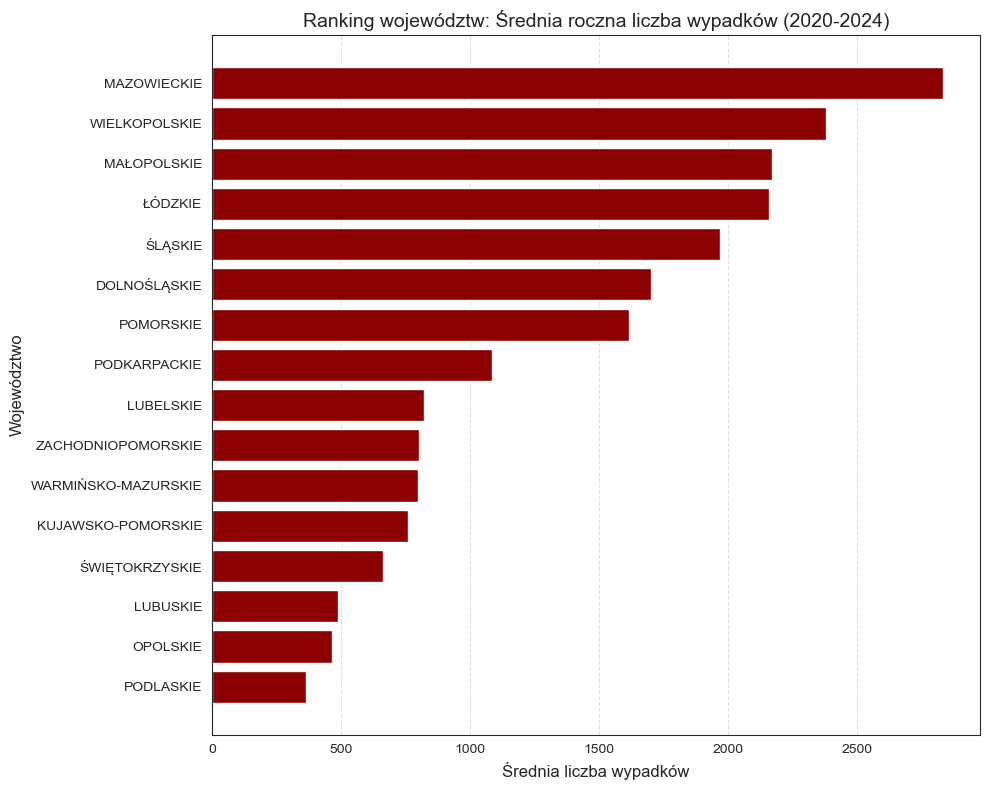

In [68]:
import matplotlib.pyplot as plt

wykres_data = df_srednie.sort_values(by='ogółem', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(wykres_data['Nazwa'], wykres_data['ogółem'], color='darkred')
plt.title('Ranking województw: Średnia roczna liczba wypadków (2020-2024)', fontsize=14)
plt.xlabel('Średnia liczba wypadków', fontsize=12)
plt.ylabel('Województwo', fontsize=12)

#siatka pomocnicza
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Powyższy wykres przedstawia ranking województw według średniej rocznej liczby wypadków w latach 2020-2024. Tak jak zostało to już omówione wyżej, najwięcej wypadków występuje w województwie mazowieckim, natomiast najmniejsze wartości notuje województwo podlaskie. Wykres ten jednoznacznie wskazuje na to, że bardziej zurbanizowane województwa mają wyższe średnie liczby wypadków.

In [69]:
wybrana_kat = 'wina pieszych - nieostrożne wejście na jezdnię' 

analiza_woj_piesi = []
df_tylko_woj = df[df['Nazwa'] != 'POLSKA']

for _, row in df_tylko_woj.iterrows():
    lata_kolumny = [f"{wybrana_kat}_{rok}" for rok in range(2020, 2025)]
    dane_seria = row[lata_kolumny].astype(float)
    
    analiza_woj_piesi.append({
        'Województwo': row['Nazwa'],
        'Średnia': dane_seria.mean(),
        'Mediana': dane_seria.median(),
        'Odch. std.': dane_seria.std(),
        'IQR': dane_seria.quantile(0.75) - dane_seria.quantile(0.25),
        'Skośność': dane_seria.skew(),
        'Kurtoza': dane_seria.kurtosis()
    })

ranking_woj_piesi = pd.DataFrame(analiza_woj_piesi).round(3)

ranking_woj_piesi = ranking_woj_piesi.sort_values(by='Średnia', ascending=False)

In [70]:
print(f"STATYSTYKI CZASOWE (2020-2024) DLA: {wybrana_kat.upper()}")
ranking_woj_piesi

STATYSTYKI CZASOWE (2020-2024) DLA: WINA PIESZYCH - NIEOSTROŻNE WEJŚCIE NA JEZDNIĘ


,Województwo,Średnia,Mediana,Odch. std.,IQR,Skośność,Kurtoza
6,MAZOWIECKIE,84.2,83.0,11.100,10.0,1.228,1.532
11,ŚLĄSKIE,83.0,77.0,22.057,17.0,0.696,0.740
5,MAŁOPOLSKIE,81.4,77.0,17.869,13.0,1.190,1.711
4,ŁÓDZKIE,66.6,72.0,17.358,25.0,0.072,-1.838
14,WIELKOPOLSKIE,59.4,58.0,6.025,6.0,1.226,1.229
0,DOLNOŚLĄSKIE,52.2,49.0,6.907,7.0,1.184,0.548
10,POMORSKIE,49.4,45.0,13.502,11.0,1.609,2.560
8,PODKARPACKIE,44.2,46.0,13.065,1.0,-1.168,2.727
2,LUBELSKIE,36.0,35.0,6.782,6.0,1.322,1.785
1,KUJAWSKO-POMORSKIE,27.6,28.0,4.037,3.0,-0.123,0.676


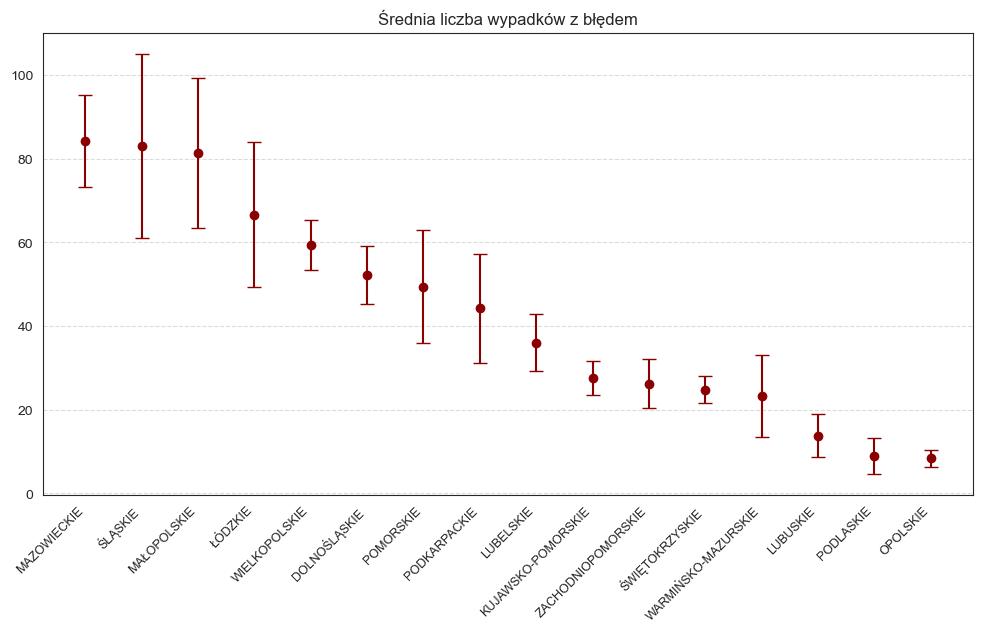

In [71]:
plt.figure(figsize=(12, 6))
plt.errorbar(ranking_woj_piesi['Województwo'], ranking_woj_piesi['Średnia'], 
             yerr=ranking_woj_piesi['Odch. std.'], fmt='o', color='darkred', capsize=5)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Średnia liczba wypadków z błędem')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Wykres przedstawia średnią liczbę wypadków z winy pieszych - nieostrożne wejście na jezdnię wraz z błędem. Największe przedziały błędu widoczne są dla województw śląskiego, małopolskiego oraz łódzkiego, co wskazuje na większe wahania liczby wypadków w czasie. Województwa z najniższą średnią charakteryzują się niewielką zmiennością.

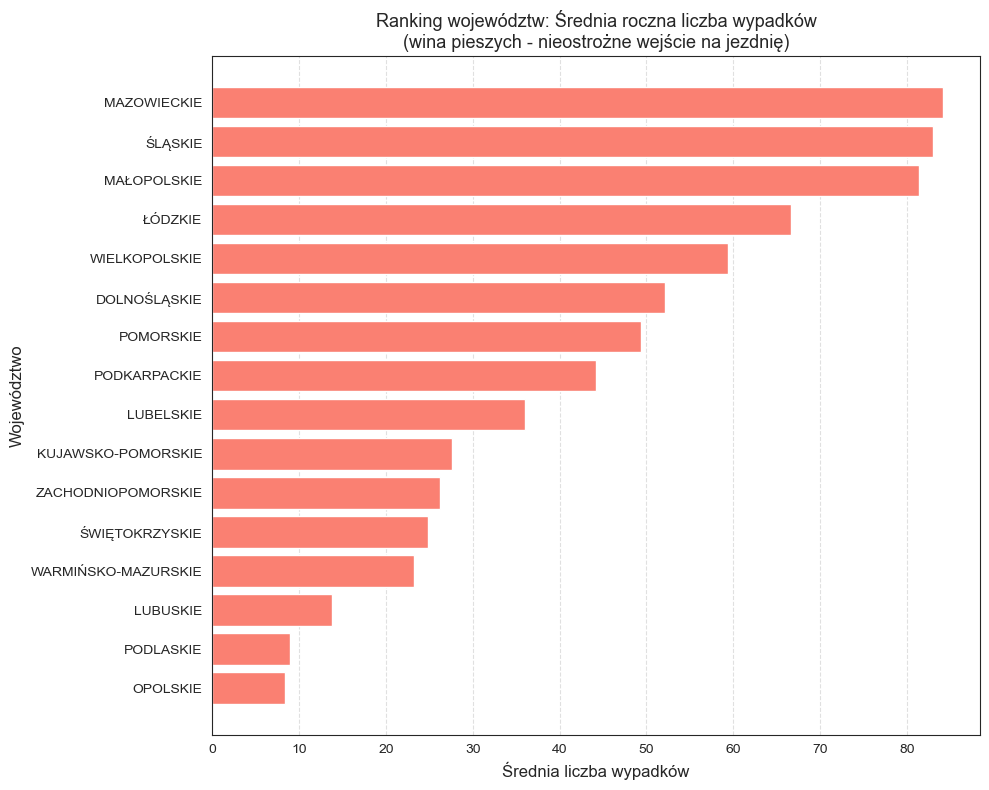

In [72]:
wykres_piesi = ranking_woj_piesi.sort_values(by='Średnia', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(wykres_piesi['Województwo'], wykres_piesi['Średnia'], color='salmon')
plt.title(f'Ranking województw: Średnia roczna liczba wypadków\n({wybrana_kat})', fontsize=13)
plt.xlabel('Średnia liczba wypadków', fontsize=12)
plt.ylabel('Województwo', fontsize=12)

#siatka pomocnicza
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Porównanie wina kierowców i wina pieszych (ogółem)')

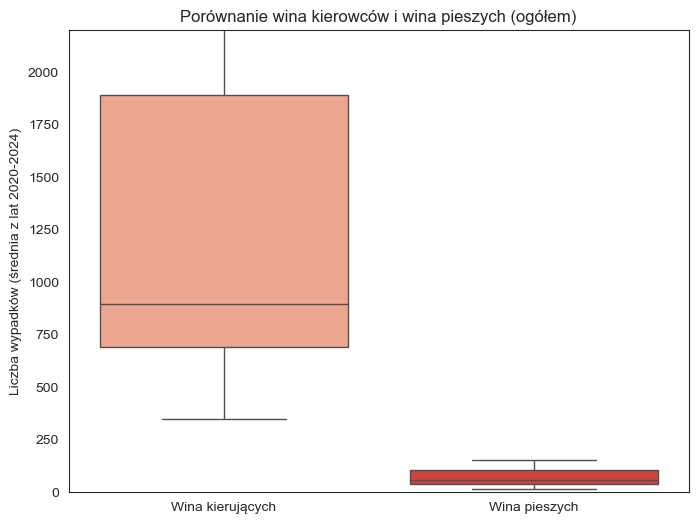

In [73]:
import seaborn as sns

df_boxplot = df_srednie[['wina kierujących pojazdami - ogółem',
                           'wina pieszych - ogółem']]

plt.figure(figsize=(8,6))

# Boxplot - pokazuje rozkład wartości
sns.boxplot(data=df_boxplot,palette="Reds")
plt.xticks([0, 1], ['Wina kierujących', 'Wina pieszych'])
plt.ylim(0,2200)
plt.ylabel("Liczba wypadków (średnia z lat 2020-2024)")
plt.title("Porównanie wina kierowców i wina pieszych (ogółem)")

Boxplot pokazuje, że zdecydowana większość wypadków przypisana jest winie kierujących, zarówno pod względem mediany, jak i rozrzutu danych. Wina kierowców charakteryzuje się bardzo dużą zmiennością między województwami,natomiast wypadki z winy pieszych są wielokrotnie mniej liczne i mają niewielki rozrzut, co potwierdza ich marginalny udział w ogólnej liczbie wypadków.

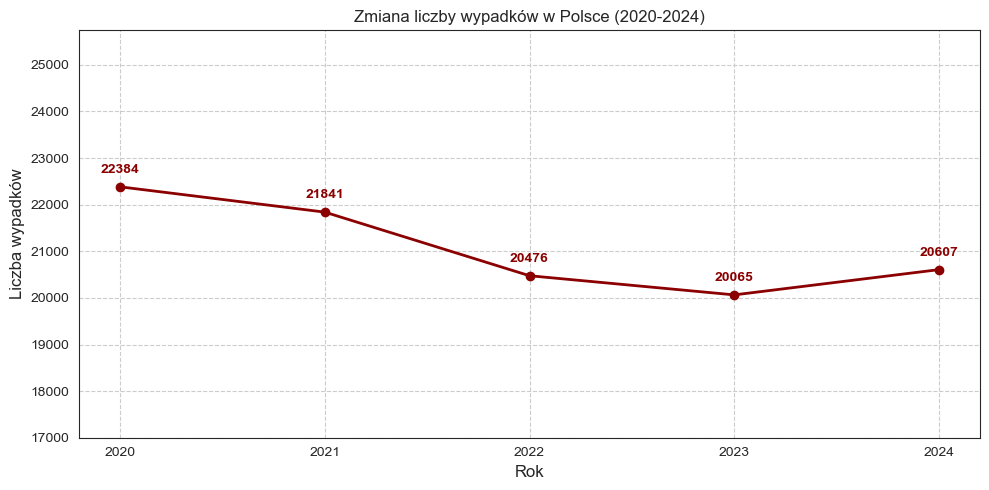

In [74]:
lata = [2020, 2021, 2022, 2023, 2024]
polska_ogolem = df[df['Nazwa'] == 'POLSKA'][[f'ogółem_{r}' for r in lata]].values.flatten()

plt.figure(figsize=(10, 5))
plt.plot(lata, polska_ogolem, marker='o', color='darkred', linewidth=2)

for i, txt in enumerate(polska_ogolem):
    plt.annotate(f'{int(txt)}', 
                 (lata[i], polska_ogolem[i]), 
                 textcoords="offset points", 
                 xytext=(0, 10), #Przesunięcie napisu 10 pkt nad punkt
                 ha='center', 
                 fontweight='bold',
                 color='darkred')
plt.xticks(lata)    
plt.ylim(17000, max(polska_ogolem) * 1.15)
plt.title('Zmiana liczby wypadków w Polsce (2020-2024)')
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Liczba wypadków', fontsize=12)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

Analiza trendu zmian liczby wypadków w Polsce w latach 2020-2024 wskazuje na wyraźną tendencję spadkową, która dominowała przez większość badanego okresu, prowadząc do sukcesywnej redukcji zdarzeń z poziomu wyjściowego 22 384 w 2020 roku do minimum w badanym okresie, 20 065 w roku 2023. W kolejnym roku nastąpiło jednak odwrócenie trendu i wystąpił wzrost liczby wypadków do poziomu 20 607. Mimo ostatniego roku, ogólny bilans pięciolecia pozostaje dodatni – w porównaniu do początku okresu, liczba zdarzeń drogowych spadła.

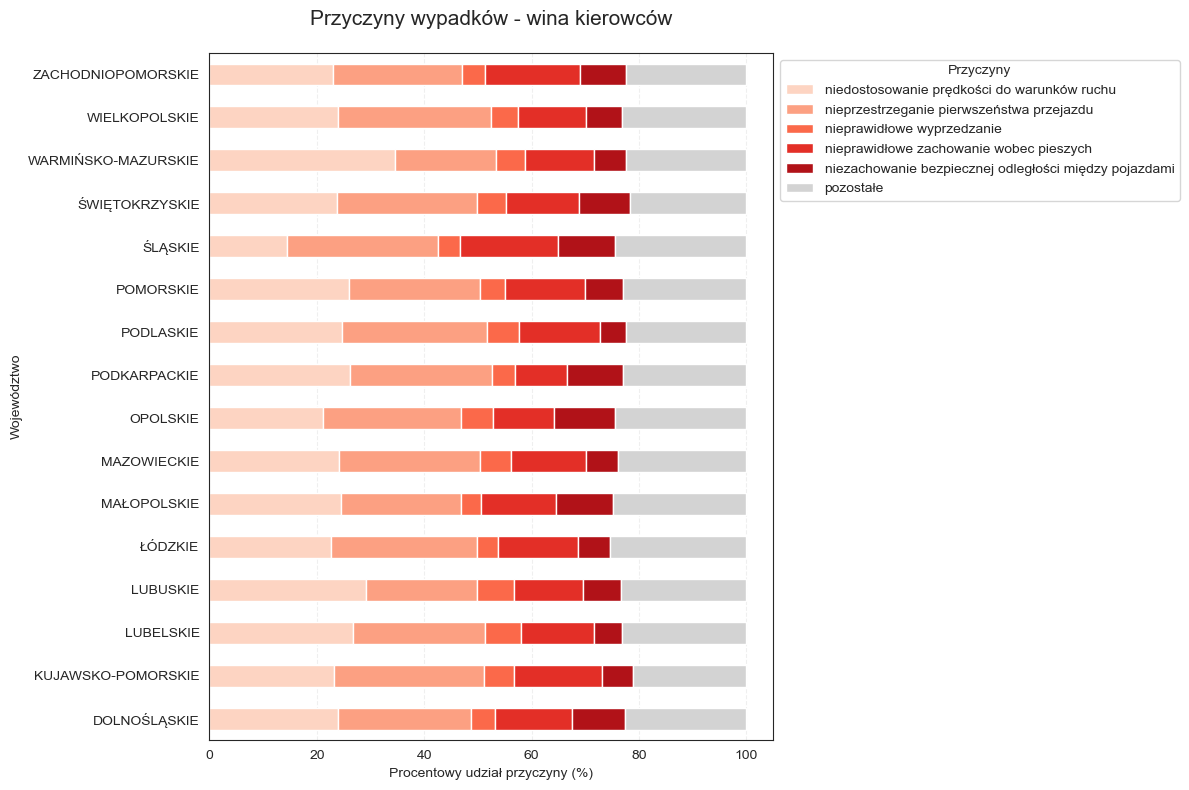

In [75]:
import seaborn as sns

przyczyny_cols = [
    'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu',
    'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu',
    'wina kierujących pojazdami - nieprawidłowe wyprzedzanie',
    'wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych',
    'wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami',
    'wina kierujących pojazdami - pozostałe'
]


#przeliczanie na procenty, zeby uzyskac sume 100%
df_przyczyny = df_srednie[df_srednie['Nazwa'] != 'POLSKA'].set_index('Nazwa')[przyczyny_cols]
df_przyczyny = df_przyczyny.div(df_przyczyny.sum(axis=1), axis=0) * 100

custom_colors = list(sns.color_palette("Reds", n_colors=5))
custom_colors.append('lightgrey')
ax = df_przyczyny.plot(kind='barh', stacked=True, figsize=(12, 8), color=custom_colors)

plt.title('Przyczyny wypadków - wina kierowców', fontsize=15, pad=20)
plt.xlabel('Procentowy udział przyczyny (%)')
plt.ylabel('Województwo')
plt.legend(title='Przyczyny', bbox_to_anchor=(1, 1), loc='upper left',

           labels=[c.split(' - ')[-1] for c in przyczyny_cols])

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Wykres przedstawia proporcje przyczyn wypadków z winy kierowcy w Polsce w badanych latach. We wszystkich województwach dominującymi przyczynami wypadków z winy kierowców są niedostosowanie prędkości do warunków ruchu oraz nieprzestrzeganie pierwszeństwa przejazdu, które łącznie stanowią niemalże 50% wszystkich wypadków z winy kierowcy. Z kolei najmniejszy udział stanowi nieprawidłowe wyprzedanie. Struktura przyczyn jest podobna we wszysztkich województwach.

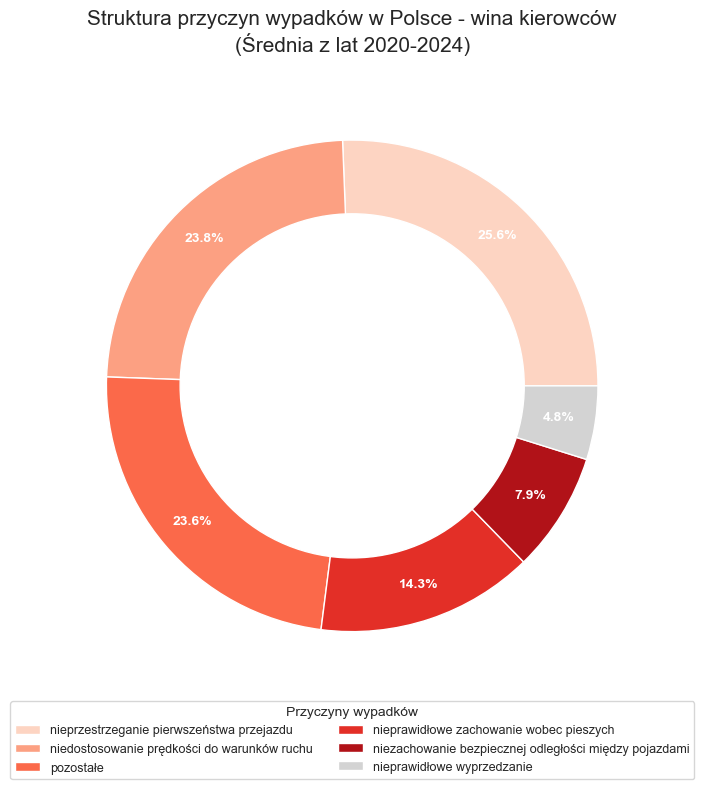

In [76]:
dane_polska = df_srednie[df_srednie['Nazwa'] != 'POLSKA'][przyczyny_cols].sum()

#sortowanie
dane_polska = dane_polska.sort_values(ascending=False)
labels_posortowane = [c.split(' - ')[-1] for c in dane_polska.index]

plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    dane_polska, 
    autopct='%1.1f%%', 
    colors=custom_colors,
    pctdistance=0.85, #przesuniecie procentow blizej krawedzi
)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.legend(
    wedges, labels_posortowane,
    title="Przyczyny wypadków",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    fontsize=9
)
plt.setp(autotexts, size=10, weight="bold", color="white")

plt.title(f'Struktura przyczyn wypadków w Polsce - wina kierowców\n(Średnia z lat 2020-2024)', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

Powyższy wykres przedstawia procentowy udział przyczyn wypadków z winy kierowców w lataach 2020-2024. Największy odsetek wypadków jest spowodowanych nieprzestrzeganiem pierszeństwa przejazdu oraz niedostosowaniem prędkości do warunków ruchu, natomiast najmniejszy nieprawidłowym wyprzedzaniem. Kategoria pozostałe również stanowi wysoki odsetek wypadków; uwzględnia ona wszelkie inne wypadki, które nie zostały wymienione w przyczynach wypadków.

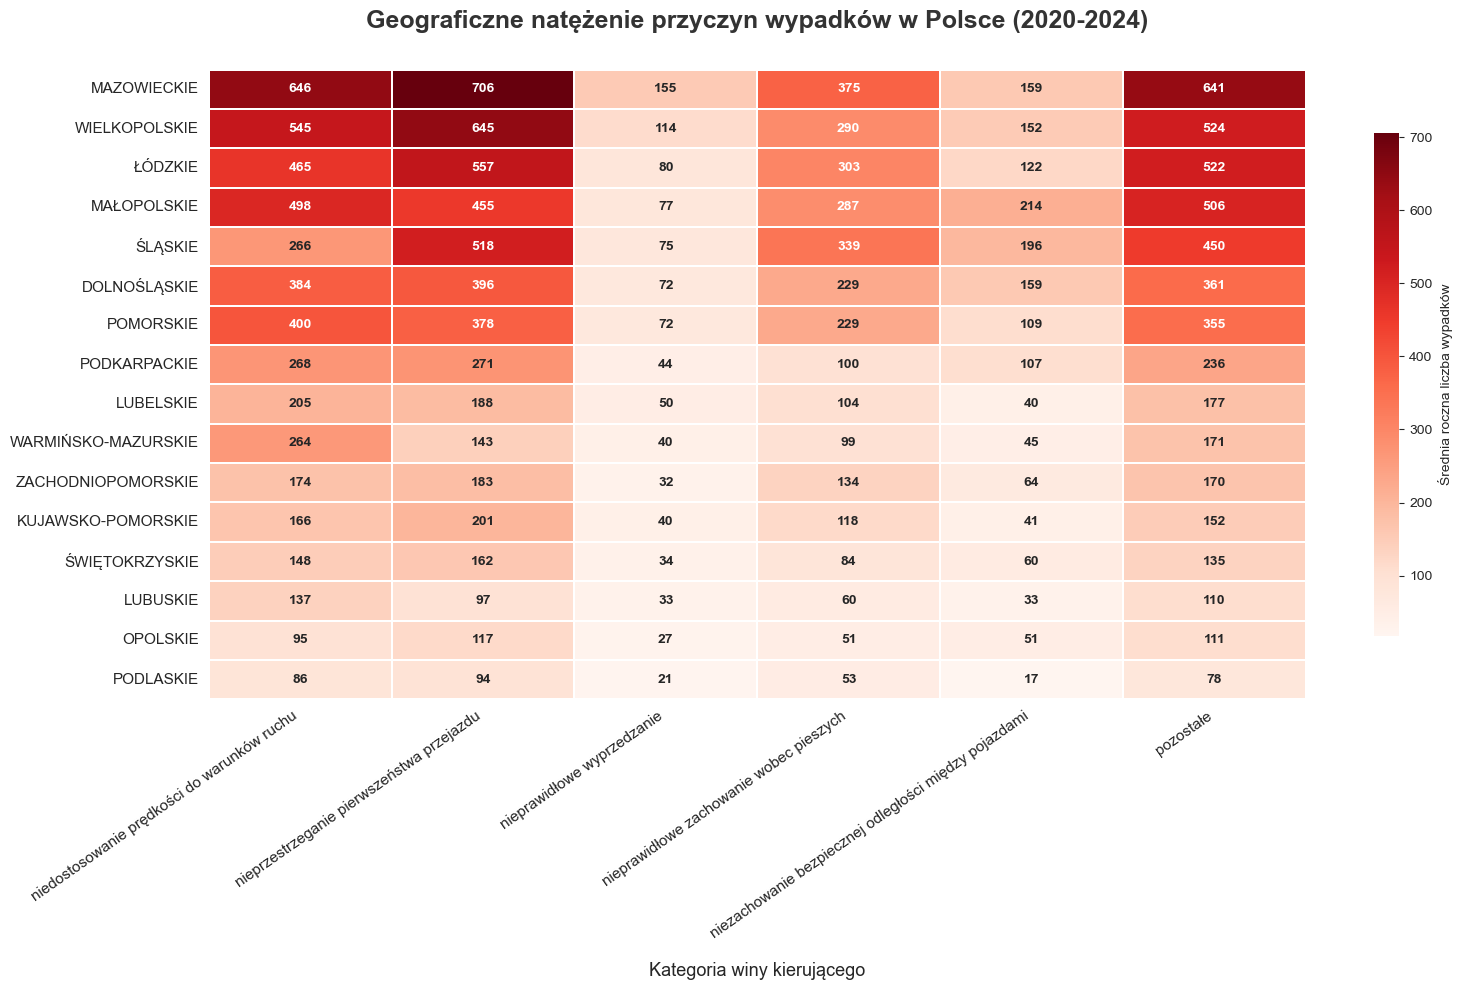

In [77]:
df_heatmap = df_srednie[df_srednie['Nazwa'] != 'POLSKA'].set_index('Nazwa')[przyczyny_cols]
df_heatmap.columns = [c.replace('wina kierujących pojazdami - ', '') for c in df_heatmap.columns]
df_heatmap = df_heatmap.apply(pd.to_numeric, errors='coerce')

df_heatmap['Suma'] = df_heatmap.sum(axis=1)
df_heatmap = df_heatmap.sort_values('Suma', ascending=False).drop('Suma', axis=1)

plt.figure(figsize=(16, 10))
sns.set_style("white")

ax = sns.heatmap(
    df_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=1.2,
    linecolor='white',
    annot_kws={"size": 10, "weight": "bold"},
    cbar_kws={"shrink": 0.8, "label": "Średnia roczna liczba wypadków"}
)
plt.title('Geograficzne natężenie przyczyn wypadków w Polsce (2020-2024)',
          fontsize=18, pad=30, fontweight='bold', color='#333333')
plt.xlabel('Kategoria winy kierującego', fontsize=13, labelpad=15)
plt.ylabel('', fontsize=13)
plt.xticks(rotation=35, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

Powyższy wykres ponownie wskazuje, że największe natężenie wypadków z winy kierowców występuje w województwach o dużej liczbie mieszkańców i natężeniu ruchu, oraz potwierdza główne przyczyny wypadków, wraz z ich czętotliwością. Wykres ten bardzo konkretnie oddziela najczęstsze przyczyny i ich regiony, wskazując bezpośrednio na najbezpieczniejsze województwa.

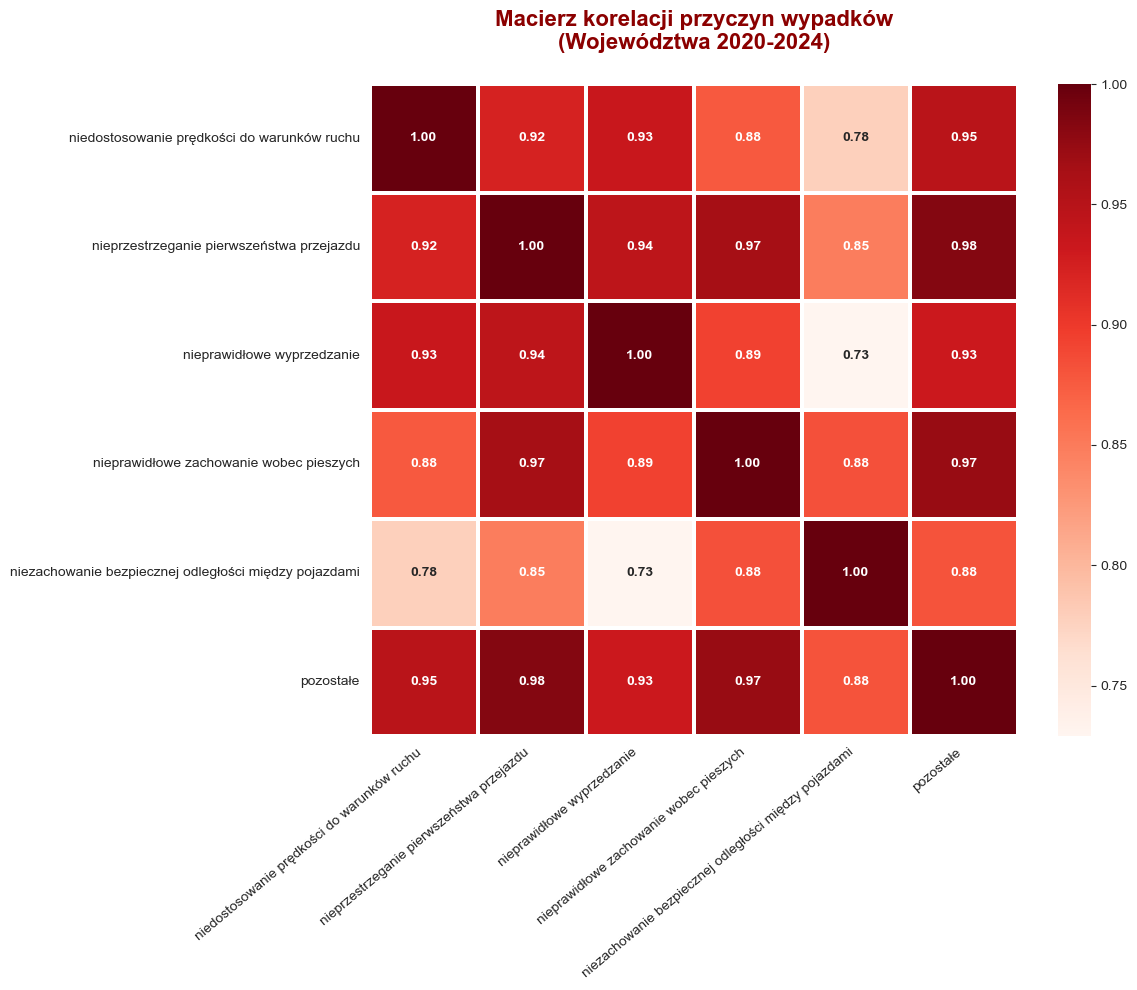

In [78]:
df_corr = df_srednie[df_srednie['Nazwa'] != 'POLSKA'][przyczyny_cols]
df_corr.columns = [c.replace('wina kierujących pojazdami - ', '') for c in df_corr.columns]
corr_matrix = df_corr.corr()
plt.figure(figsize=(12, 10))
sns.set_style("white")

sns.heatmap(
    corr_matrix, 
    annot=True, #wspolczynniki 0.0 - 1.0
    fmt=".2f", 
    cmap="Reds", 
    linewidths=1.5, 
    linecolor='white',
    annot_kws={"size": 10, "weight": "bold"}
)

plt.title('Macierz korelacji przyczyn wypadków\n(Województwa 2020-2024)', 
          fontsize=16, pad=25, fontweight='bold', color='darkred')

plt.xticks(rotation=40, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


Macierz korelacji pokazuje bardzo silne dodatnie zależności między wszystkimi analizowanymi przyczynami wypadków w województwach w latach 2020–2024, co oznacza, że regiony z wysoką liczbą wypadków w jednej kategorii zwykle notują także wysokie wartości w pozostałych. Najsilniejsze korelacje występują między nieprzestrzeganiem pierwszeństwa przejazdu oraz nieprawidłowym zachowaniem wobec pieszych, natomiast relatywnie najsłabsza, choć nadal wysoka zależność dotyczy niezachowania bezpiecznej odległości między pojazdami i nieprawidłowego wyprzedzania. 